<div style="text-align: center;">
    <h1 style="color: navy;">Projet LO12 - Algorithme Apriori</h1>
    <h3 style="color: darkslategray;">Systèmes à base de règles avec CLIPS</h3>
</div>

<div>
    <h2 style="color: darkslategray;">1. Introduction</h2>
    <p style="color: dimgray;">
        Ce notebook applique l'algorithme <strong style="color: seagreen;">Apriori</strong> sur un dataset de paniers d'achat.
        Le but est de trouver des produits souvent achetés ensemble, puis d'utiliser quelques résultats
        comme règles dans <strong style="color: seagreen;">CLIPS</strong>.
    </p>
</div>

<div>
    <h2 style="color: darkslategray;">2. Qu'est-ce que CLIPS ?</h2>
    <p style="color: dimgray;">
        <strong>CLIPS</strong> est un outil permettant de créer des systèmes experts à base de règles.
        Une règle CLIPS fonctionne généralement avec une logique de type :
        <strong>SI une condition est vraie, ALORS une action est déclenchée</strong>.
    </p>
    <p style="color: dimgray;">
        Dans ce projet, l'algorithme <strong>Apriori</strong> permet de découvrir automatiquement des associations
        fréquentes entre les produits. Ensuite, certaines de ces associations sont traduites en règles CLIPS
        afin de construire un système de recommandation explicable.
    </p>
    <p style="color: dimgray;">
        Exemple : si Apriori montre que les clients qui achètent <code>whole_milk</code> achètent souvent
        <code>yogurt</code>, alors on peut écrire une règle CLIPS qui recommande <code>yogurt</code>
        lorsqu'un panier contient <code>whole_milk</code>.
    </p>
</div>

<div>
    <h2 style="color: darkslategray;">3. Importation des bibliothèques</h2>
    <p style="color: dimgray;">
        On importe les bibliothèques nécessaires pour lire les données, les transformer et appliquer Apriori.
    </p>
</div>

In [1]:
import pandas as pd
import numpy as np
import collections

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.max_columns", 35)
pd.set_option("display.max_rows", 200)

<div>
    <h2 style="color: darkslategray;">4. Chargement du dataset</h2>
    <p style="color: dimgray;">
        Le dataset contient des transactions de type panier d'achat.
        Chaque ligne correspond à un panier et chaque colonne contient un produit.
    </p>
</div>

In [2]:
dataset = pd.read_csv("data/groceries - groceries.csv")

dataset.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,Item 10,Item 11,Item 12,Item 13,Item 14,Item 15,Item 16,Item 17,Item 18,Item 19,Item 20,Item 21,Item 22,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
dataset.shape

(9835, 33)

<div>
    <h2 style="color: darkslategray;">5. Vérification des données</h2>
    <p style="color: dimgray;">
        On vérifie rapidement le type d'une valeur pour comprendre comment les articles sont stockés.
    </p>
</div>

In [4]:
type(dataset["Item 5"][0])

float

<div>
    <h2 style="color: darkslategray;">6. Transformation en transactions</h2>
    <p style="color: dimgray;">
        On transforme chaque ligne en liste de produits, en supprimant les valeurs vides.
    </p>
</div>

In [5]:
market = []

for i in range(dataset.shape[0]):
    transaction = []

    for col in dataset.columns:
        if isinstance(dataset[col][i], str):
            transaction.append(dataset[col][i])
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
    market.append(transaction)

market[:5]

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product']]

<div>
    <h2 style="color: darkslategray;">7. Comptage des produits</h2>
    <p style="color: dimgray;">
        Cette étape permet d'afficher les produits les plus fréquents dans le dataset.
    </p>
</div>

In [6]:
all_items = []

for transaction in market:
    for item in transaction:
        all_items.append(item)

counter = collections.Counter(all_items)

items_count = pd.DataFrame({
    "Item Name": counter.keys(),
    "Values": counter.values()
})

items_count.sort_values(by="Values", ascending=False).head(20)

,Item Name,Values
7,whole milk,2513
11,other vegetables,1903
17,rolls/buns,1809
31,soda,1715
5,yogurt,1372
24,bottled water,1087
42,root vegetables,1072
4,tropical fruit,1032
52,shopping bags,969
50,sausage,924


<div>
    <h2 style="color: darkslategray;">7. Vérification complémentaire des données</h2>
    <p style="color: dimgray;">
        Cette partie vérifie la taille du dataset, les valeurs manquantes, les doublons,
        le nombre de produits différents et la taille des paniers.
    </p>
</div>

In [7]:
# Vérification complémentaire des données
print("Nombre de transactions :", dataset.shape[0])
print("Nombre de colonnes :", dataset.shape[1])
print("Nombre total de valeurs manquantes :", dataset.isna().sum().sum())
print("Nombre de lignes dupliquées :", dataset.duplicated().sum())

basket_sizes = [len(transaction) for transaction in market]

print("Nombre de produits différents :", len(set(all_items)))
print("Taille minimale d'un panier :", min(basket_sizes))
print("Taille maximale d'un panier :", max(basket_sizes))
print("Taille moyenne d'un panier :", round(np.mean(basket_sizes), 2))

Nombre de transactions : 9835
Nombre de colonnes : 33
Nombre total de valeurs manquantes : 271353
Nombre de lignes dupliquées : 2824
Nombre de produits différents : 169
Taille minimale d'un panier : 1
Taille maximale d'un panier : 32
Taille moyenne d'un panier : 4.41


<div>
    <h2 style="color: darkslategray;">8. Analyse exploratoire des données</h2>
    <p style="color: dimgray;">
        L'objectif est de mieux comprendre le contenu des paniers avant d'utiliser Apriori.
        On observe ici les produits les plus fréquents et la distribution de la taille des paniers.
    </p>
</div>

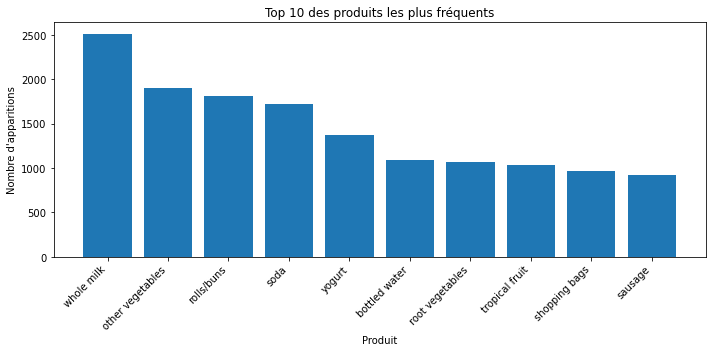

In [8]:
import matplotlib.pyplot as plt

# Top 10 des produits les plus fréquents
top_items = items_count.sort_values(by="Values", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_items["Item Name"], top_items["Values"])
plt.title("Top 10 des produits les plus fréquents")
plt.xlabel("Produit")
plt.ylabel("Nombre d'apparitions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

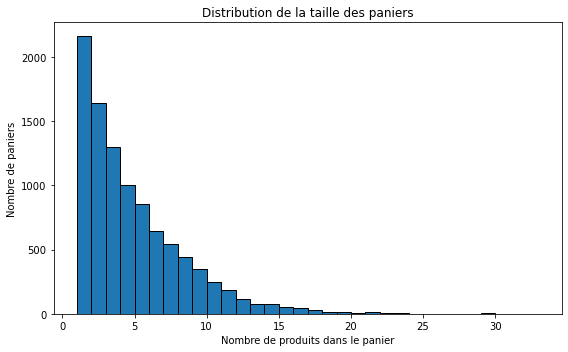

In [9]:
# Distribution de la taille des paniers
plt.figure(figsize=(8, 5))
plt.hist(basket_sizes, bins=range(1, max(basket_sizes) + 2), edgecolor="black")
plt.title("Distribution de la taille des paniers")
plt.xlabel("Nombre de produits dans le panier")
plt.ylabel("Nombre de paniers")
plt.tight_layout()
plt.show()

<div>
    <h2 style="color: darkslategray;">9. Paires de produits les plus fréquentes</h2>
    <p style="color: dimgray;">
        Cette analyse permet de voir directement quels produits apparaissent souvent ensemble,
        indépendamment des métriques support, confiance et lift.
    </p>
</div>

In [23]:
from itertools import combinations

pair_counter = collections.Counter()

for transaction in market:
    unique_items = sorted(set(transaction))
    for pair in combinations(unique_items, 2):
        pair_counter[pair] += 1

pair_counts = pd.DataFrame([
    {"Produit 1": pair[0], "Produit 2": pair[1], "Fréquence": count}
    for pair, count in pair_counter.items()
])

pair_counts = pair_counts.sort_values(by="Fréquence", ascending=False)
pair_counts.head(10)

,Produit 1,Produit 2,Fréquence
20,other vegetables,whole milk,736
506,rolls/buns,whole milk,557
30,whole milk,yogurt,551
206,root vegetables,whole milk,481
137,other vegetables,root vegetables,466
1066,other vegetables,yogurt,427
40,other vegetables,rolls/buns,419
82,tropical fruit,whole milk,416
232,soda,whole milk,394
85,rolls/buns,soda,377


<div>
    <h2 style="color: darkslategray;">10. Encodage des transactions</h2>
    <p style="color: dimgray;">
        Les transactions sont converties en matrice booléenne pour être utilisées par Apriori.
    </p>
</div>

In [24]:
transaction_encoder = TransactionEncoder()

encoded_array = transaction_encoder.fit(market).transform(market)

df = pd.DataFrame(encoded_array, columns=transaction_encoder.columns_)

df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,...,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


<div>
    <h2 style="color: darkslategray;">12. Justification des paramètres Apriori</h2>
    <p style="color: dimgray;">
        Dans ce notebook, le seuil de support minimal est fixé à <strong>0.05</strong>.
        Cela signifie qu'un ensemble de produits doit apparaître dans au moins 5% des transactions
        pour être considéré comme fréquent.
    </p>
    <p style="color: dimgray;">
        La confiance minimale est fixée à <strong>0.30</strong>. Une règle est donc conservée si,
        lorsque l'antécédent est présent, le conséquent apparaît dans au moins 30% des cas.
    </p>
    <p style="color: dimgray;">
        Le paramètre <code>max_len=2</code> limite l'analyse aux associations entre deux produits,
        ce qui facilite l'interprétation et la conversion en règles CLIPS simples.
    </p>
</div>

<div>
    <h2 style="color: darkslategray;">13. Application de l'algorithme Apriori</h2>
    <p style="color: dimgray;">
        On garde les groupes de produits présents dans au moins <strong style="color: seagreen;">5%</strong> des transactions.
    </p>
</div>

In [12]:
frequent_itemsets = apriori(
    df,
    min_support=0.05,
    use_colnames=True,
    max_len=2
)

frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

frequent_itemsets

,support,itemsets
26,0.255516,(whole milk)
15,0.193493,(other vegetables)
19,0.183935,(rolls/buns)
23,0.174377,(soda)
27,0.139502,(yogurt)
2,0.110524,(bottled water)
20,0.108998,(root vegetables)
24,0.104931,(tropical fruit)
22,0.098526,(shopping bags)
21,0.093950,(sausage)


<div>
    <h2 style="color: darkslategray;">14. Génération des règles d'association</h2>
    <p style="color: dimgray;">
        Les règles ont la forme : si un client achète un produit, alors il peut aussi acheter un autre produit.
    </p>
</div>

In [13]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

rules = rules.sort_values(by=["confidence", "lift"], ascending=False)

rules[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
2,(yogurt),(whole milk),0.056024,0.401603,1.571735
0,(other vegetables),(whole milk),0.074835,0.386758,1.513634
1,(rolls/buns),(whole milk),0.056634,0.307905,1.205032


<div>
    <h2 style="color: darkslategray;">15. Interprétation des règles</h2>
    <p style="color: dimgray;">
        On affiche quelques règles sous forme de phrases simples.
    </p>
</div>

In [14]:
for index, row in rules.head(10).iterrows():
    antecedent = list(row["antecedents"])
    consequent = list(row["consequents"])

    print(f"Si un client achète {antecedent}, alors il est probable qu'il achète {consequent}.")
    print(f"Support : {row['support']:.3f}")
    print(f"Confiance : {row['confidence']:.3f}")
    print(f"Lift : {row['lift']:.3f}")
    print("-" * 60)

Si un client achète ['yogurt'], alors il est probable qu'il achète ['whole milk'].
Support : 0.056
Confiance : 0.402
Lift : 1.572
------------------------------------------------------------
Si un client achète ['other vegetables'], alors il est probable qu'il achète ['whole milk'].
Support : 0.075
Confiance : 0.387
Lift : 1.514
------------------------------------------------------------
Si un client achète ['rolls/buns'], alors il est probable qu'il achète ['whole milk'].
Support : 0.057
Confiance : 0.308
Lift : 1.205
------------------------------------------------------------


<div>
    <h2 style="color: darkslategray;">16. Recommandations concrètes pour un vendeur</h2>
    <p style="color: dimgray;">
        Cette partie transforme les résultats Apriori en conseils pratiques pour un vendeur.
        Les règles avec un <strong>lift élevé</strong> sont intéressantes car elles indiquent une association plus forte
        que le hasard entre deux produits.
    </p>
</div>

In [32]:
def itemset_to_text(itemset):
    return ", ".join(list(itemset))

business_recommendations = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
business_recommendations = business_recommendations.sort_values(by=["lift", "confidence"], ascending=False)

for index, row in business_recommendations.head(7).iterrows():
    antecedent = itemset_to_text(row["antecedents"])
    consequent = itemset_to_text(row["consequents"])

    print(f"Si un client achète : {antecedent}")
    print(f"Produit à recommander : {consequent}")
    print("Conseil vendeur : placer ces produits proches, créer une promotion groupée ou proposer le produit à la caisse.")
    print(f"Support : {row['support']:.3f} | Confiance : {row['confidence']:.3f} | Lift : {row['lift']:.3f}")
    print("-" * 90)

Si un client achète : yogurt
Produit à recommander : whole milk
Conseil vendeur : placer ces produits proches, créer une promotion groupée ou proposer le produit à la caisse.
Support : 0.056 | Confiance : 0.402 | Lift : 1.572
------------------------------------------------------------------------------------------
Si un client achète : other vegetables
Produit à recommander : whole milk
Conseil vendeur : placer ces produits proches, créer une promotion groupée ou proposer le produit à la caisse.
Support : 0.075 | Confiance : 0.387 | Lift : 1.514
------------------------------------------------------------------------------------------
Si un client achète : rolls/buns
Produit à recommander : whole milk
Conseil vendeur : placer ces produits proches, créer une promotion groupée ou proposer le produit à la caisse.
Support : 0.057 | Confiance : 0.308 | Lift : 1.205
------------------------------------------------------------------------------------------


<div>
    <h2 style="color: darkslategray;">17. Lien avec le fichier CLIPS</h2>
    <p style="color: dimgray;">
        La partie CLIPS est réalisée dans un fichier séparé nommé <code>exemples(1).clp</code>.
        Ce fichier contient des règles de recommandation construites à partir de règles Apriori.
    </p>
    <p style="color: dimgray;">
        Les faits <code>basket</code> représentent les produits présents dans un panier.
        Les faits <code>recommendation</code> représentent les produits proposés par le système expert.
    </p>
</div>

In [33]:
# Aperçu du fichier CLIPS
from pathlib import Path

clips_file = Path("clips/apriori_rules_examples.clp")

if clips_file.exists():
    with open(clips_file, "r", encoding="utf-8") as file:
        clips_lines = file.readlines()

    print("Aperçu des 40 premières lignes du fichier CLIPS :")
    print("".join(clips_lines[:40]))
else:
    print("Le fichier exemples(1).clp n'est pas dans le même dossier que le notebook.")
    print("Placez le fichier .clp à côté du notebook pour afficher son aperçu ici.")

Aperçu des 40 premières lignes du fichier CLIPS :
; ============================================================
; Projet LO12 - Partie CLIPS
; Systeme de recommandation avec plusieurs exemples de test
; ============================================================

; ------------------------------------------------------------
; 1. Structures utilisees
; ------------------------------------------------------------

(deftemplate basket
   (slot example)
   (slot item)
)

(deftemplate recommendation
   (slot example)
   (slot from)
   (slot item)
)

; ------------------------------------------------------------
; 2. Message de debut
; ------------------------------------------------------------

(defrule show_start
   (declare (salience 100))
   =>
   (printout t crlf)
   (printout t "==================== SYSTEME DE RECOMMANDATION ====================" crlf)
   (printout t "Ce fichier teste plusieurs paniers differents." crlf)
   (printout t "Chaque exemple montre quelles regles Apriori 

<div>
    <h2 style="color: darkslategray;">18. Commandes pour exécuter le fichier CLIPS</h2>
    <p style="color: dimgray;">
        Dans CLIPS, les commandes suivantes permettent de charger et tester le système de recommandation :
    </p>
</div>

```clips
(load "exemples(1).clp")
(reset)
(run)
(facts)
```

Après l'exécution, CLIPS affiche les règles activées et les recommandations générées pour chaque panier de test.

<div>
    <h2 style="color: darkslategray;">19. Conclusion générale</h2>
    <p style="color: dimgray;">
        Ce projet montre la complémentarité entre l'apprentissage automatique et les systèmes à base de règles.
        L'algorithme Apriori découvre automatiquement les associations fréquentes dans les paniers d'achat.
        CLIPS permet ensuite d'exploiter ces associations sous forme de règles explicites et faciles à expliquer.
    </p>
    <p style="color: dimgray;">
        Les résultats peuvent être utiles pour un vendeur, par exemple pour proposer des recommandations,
        organiser les rayons ou construire des offres groupées.
    </p>
</div>